In [1]:
import importlib
import helpers

importlib.reload(helpers)

<module 'helpers' from 'C:\\Users\\hmorl\\Projects\\voting-intention-analysis\\analysis\\helpers.py'>

In [2]:
import os
import warnings

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", message="y_pred contains classes not in y_true")
warnings.filterwarnings("ignore", message="The least populated class in y")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, permutation_test_score
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier

from config import RAW_DATA_PATH, PROJECT_ROOT, TARGET_COL, DECIDED_PARTIES, ATTITUDE_PREFIX, ECON_AXIS
import helpers
import inspection
import clean
import encode
import model
import make_figures

### Load Data

In [3]:
raw_data = pd.read_csv(RAW_DATA_PATH, encoding="utf-8")
raw_data.head(5)

,serial_number,gender,age,actual_age,which_of_the_following_best_describes_your_current_working_status,which_one_of_these_regions_do_you_live_in,what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted,work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for,do_you_work_in,political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics,...,general_attitudes_britain_is_stronger_when_it_forms_partnerships_with_other_countries,general_attitudes_i_worry_that_cuts_in_defence_spending_mean_britain_can_no_longer_defend_itself,general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies,general_attitudes_there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today,general_attitudes_government_should_always_put_the_needs_of_british_people_ahead_of_others,general_attitudes_the_uk_should_be_more_outward_looking_in_nature,general_attitudes_i_consider_myself_working_class,general_attitudes_big_business_takes_advantage_of_ordinary_people,goal_importance_most_important,voting_intention_which_party_would_you_vote_for_if_there_was_a_general_election_tomorrow
0,13,Male,65+,77,Retired on a state pension only,East of England,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,...,Agree slightly,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Disagree strongly,Conserving the oceans,Conservative
1,14,Female,55-64,63,Retired with a private pension,West Midlands,"ú14,001 to ú21,000",Private sector firm or company (e.g. limited c...,NaN,A great deal,...,Neither agree nor disagree,Agree slightly,Agree slightly,Agree strongly,Agree strongly,Neither agree nor disagree,Disagree slightly,Agree slightly,"Industry, innovation, and infrastructure",Conservative
2,17,Female,65+,65,Retired on a state pension only,London,Prefer not to answer,Private sector firm or company (e.g. limited c...,NaN,Not very much,...,Agree strongly,Agree slightly,Neither agree nor disagree,Neither agree nor disagree,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Conserving life on land,Liberal Democrat
3,18,Male,45-54,49,Working full time - working 30 hours per week ...,South West,"ú34,001 to ú41,000",Private sector firm or company (e.g. limited c...,NaN,Quite a lot,...,Agree strongly,Agree slightly,Disagree slightly,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Neither agree nor disagree,Stopping climate change,Labour
4,19,Female,18-24,24,"House person, housewife, househusband, etc.",West Midlands,"ú7,001 to ú14,000",Private sector firm or company (e.g. limited c...,NaN,Some,...,Disagree slightly,Agree slightly,Neither agree nor disagree,Agree slightly,Agree strongly,Agree slightly,Agree slightly,Don't know,Providing quality education,Don't know


### Visualise and inspect the data

Before cleaning anything I want to understand what's actually in the data: the overall structure, what each response looks like, where it's missing, and any quirks that will shape how I clean and encode it later. I'll start with a high-level summary.

In [4]:
summary = pd.DataFrame({
    "dtype":       raw_data.dtypes,
    "n_unique":    raw_data.nunique(dropna=True),
    "n_missing":   raw_data.isna().sum(),
    "pct_missing": (raw_data.isna().mean() * 100).round(1),
    "example":     raw_data.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else None),
})
summary

,dtype,n_unique,n_missing,pct_missing,example
serial_number,int64,1468,0,0.0,13
gender,str,3,0,0.0,Male
age,str,6,0,0.0,65+
actual_age,int64,71,0,0.0,77
which_of_the_following_best_describes_your_current_working_status,str,7,0,0.0,Retired on a state pension only
which_one_of_these_regions_do_you_live_in,str,11,0,0.0,East of England
what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted,str,14,0,0.0,"ú14,001 to ú21,000"
work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for,str,8,0,0.0,Private sector firm or company (e.g. limited c...
do_you_work_in,str,5,1123,74.9,Other
political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics,str,5,0,0.0,A great deal


A few things stand out already, and each is worth a closer look before I commit to any cleaning steps:

- Only two columns are numeric: `serial_number` and `actual_age`. I need to explore out what `serial_number` represents - a unique respondent id, are there repeated rows? And `actual_age` overlaps with the banded `age` column, so I have two measures of the same thing.
- Most columns are string categoricals - `yes`/`no`, or the agree/disagree scale (`Agree strongly` ... `Disagree strongly`). The scaled items can be mapped to numbers for modelling, but first I want to check whether people use the scale differently from one another (some lean agree, some sit on the fence), which would justify normalising per respondent.
- Those scaled items also carry a `Don't know` option, which needs handling rather than just dropping.
- A handful of columns have a lot of unique values (e.g. household income and `goal_importance_most_important`). I should confirm these are categoricals with many bands, not free text.
- `which_of_the_following_statements_apply_to_you_dont_know` has only one unique value, so it can't tell parties apart - a candidate to drop.
- The income column looks like it has an encoding problem: the `£` sign has been mangled (e.g. `ú14,001 to ú21,000`).
- Several columns are missing data, a couple of them more than half. Whether those blanks are informative or just noise decides whether I keep or drop them.

#### Serial number: identifier or duplicates?

First, is `serial_number` a clean unique id per respondent, or are some rows repeated?

In [5]:
is_unique = raw_data["serial_number"].is_unique
print("serial_number is unique for every row" if is_unique
      else "serial_number is NOT unique - some values repeat")

# where do the repeats happen, and are the repeated rows actually identical?
inspection.repeated_serials(raw_data)

serial_number is NOT unique - some values repeat


,serial_number,n_duplicated_rows,all_identical
0,200,32,True


There's a single serial number that appears 32 times, and every one of those rows is identical. That looks like an administrative error where one response got duplicated, rather than 32 real people - so in cleaning I'll drop the duplicates and keep one copy (`clean.drop_duplicate_records`).

#### A column with only one answer

The summary flagged `which_of_the_following_statements_apply_to_you_dont_know` as having a single unique value. Confirming that...

In [6]:
raw_data["which_of_the_following_statements_apply_to_you_dont_know"].value_counts(dropna=False)

which_of_the_following_statements_apply_to_you_dont_know
No    1499
Name: count, dtype: int64

Everyone answered `no`, so the column carries no information and can't help separate voters. I'll drop it during cleaning.

#### Free text, or just many categories?

Some columns have a lot of distinct values. I want to make sure those are genuine categoricals (income bands and the like) and not free-text fields that would need different handling. A quick way to check is to look for one-off responses that appear only once.

In [7]:
inspection.rare_responses(raw_data, threshold=2)

,column,value,count
0,gender,Prefer not to say,1


Only `gender` has a value that appears once, and it's a legitimate category rather than a typed-in response. The high-cardinality columns (income, goal importance) are categoricals with many fixed options - no free text to worry about.

#### Household income: encoding and ordering

The income column had two things to check: the mangled `£` symbol, and whether the bands are ordered ranges I can treat as a scale.

In [8]:
income_col = "what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted"
inspection.response_counts(raw_data, income_col)

,n,pct
response,,
"ú14,001 to ú21,000",289,19.3
"ú21,001 to ú28,000",247,16.5
"ú7,001 to ú14,000",194,12.9
"ú28,001 to ú34,000",172,11.5
"ú34,001 to ú41,000",161,10.7
Prefer not to answer,136,9.1
"ú41,001 to ú48,000",87,5.8
"Up to ú7,000",70,4.7
"ú48,001 to ú55,000",56,3.7


The mojibake is present across the labels - this is presumably an encoding issue from how the file was saved, and I fix it in cleaning with `clean.fix_encoding_errors`. More importantly, the bands are consecutive income ranges, so they have a natural order: I can encode them ordinally (`encode.encode_income`), keeping a separate flag for the "prefer not to answer" responses.

#### Two measures of age

`age` is a banded category and `actual_age` is the continuous value. Before choosing between them I want to confirm they agree - that the bands really are slices of the continuous age.

In [9]:
raw_data.groupby("age")["actual_age"].agg(["min", "max"]).sort_index()

,min,max
age,,
18-24,18,24
25-34,25,34
35-44,35,44
45-54,45,54
55-64,55,64
65+,65,93


The bands line up cleanly with the continuous ages. I'll lean on the banded `age` for profiling (it reads clearly in plots and tables) and keep the continuous version available.

#### 'Don't know' responses and scale usage

The agree/disagree items all offer `Don't know`. Before deciding how to treat it I want to know how common it is, and whether it's spread evenly or concentrated in particular people - someone who answers `Don't know` to everything is perhaps different from someone who just skips the odd item. I also want to check whether people use the agree/disagree scale itself differently from one another (some lean agree, some sit on the fence), which would justify normalising per respondent.

In [10]:
# per-item: how often is each question answered 'Don't know'
inspection.dont_know_by_item(raw_data)

,n_dont_know,%_dont_know
item,,
general_attitudes_keeping_a_tight_control_over_spending_should_be_the_governments_main_economic_priority,98,6.5
general_attitudes_the_uk_should_be_more_outward_looking_in_nature,87,5.8
general_attitudes_britain_is_stronger_when_it_forms_partnerships_with_other_countries,83,5.5
general_attitudes_i_worry_that_cuts_in_defence_spending_mean_britain_can_no_longer_defend_itself,83,5.5
general_attitudes_britain_is_the_greatest_country_in_the_world,60,4.0
general_attitudes_big_business_takes_advantage_of_ordinary_people,60,4.0
general_attitudes_tackling_poverty_and_inequality_should_be_the_governments_top_priority,58,3.9
general_attitudes_there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today,58,3.9
general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies,56,3.7


In [11]:
# per-respondent: how many 'Don't know' answers each person gave
inspection.respondents_by_dont_know_count(raw_data)

1499 respondents across 11 attitudinal items
  246 (16.4%) gave at least one 'Don't know'
  23 (1.5%) answered 'Don't know' to all 11 items


n_dont_know
11      23
10       4
9        4
8        2
7        2
6        4
5        8
4       14
3       17
2       44
1      124
0     1253
Name: n_respondents, dtype: int64

wrote 02_response_style.png


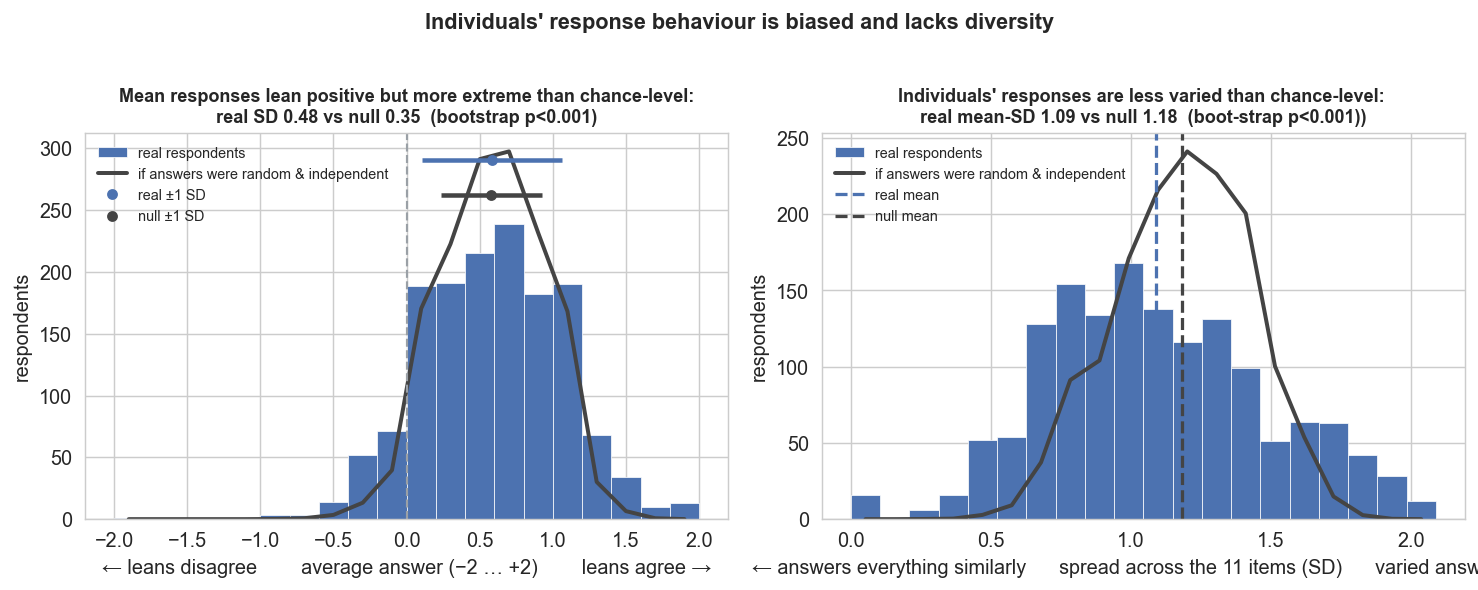

In [12]:
# do people use the agree/disagree scale differently from one another?
importlib.reload(make_figures)
import make_figures
make_figures.response_style(raw_data)

Two things stand out.

**`Don't know` is common and concentrated.** Each item draws it from ~3-7% of people, but it clusters in particular respondents - 246 (16.4%) give at least one and 23 (1.5%) answer `Don't know` to all 11 items. That looks like disengagement worth capturing rather than discarding, so I'll engineer a `dk_rate` feature (the share of items a person answered `Don't know`).

**People use the scale differently.** The histograms show respondents generally lean towards agree in their responses, but tend to lean more towards the extremes of the agree/disagree scale comapred to chance. Respondents also use less of the scale (ie less varied in their responses) than chance. Chance-level here is a null in which answers carry *no* personal response style: I build 1000 simulated cohorts (each the same size as the real sample) where every respondent's 11 answers are drawn independently, each item sampled from its *own* observed answer distribution. This keeps each question's real answer spread but breaks the link between a person and their set of answers, so any per-person lean or consistency is destroyed — the grey curve is this null. Each panel then gets its own one-sided p-value: how often a null cohort is as *spread out* in its per-person means as the real data (left), and how often a null cohort's average within-person variation is as *small* as the real data (right). To separate this personal response style from genuine opinions , I normalise *within each respondent* - map the agree/disagree scale to `-2`...`+2` and z-score against the person's own mean and spread - and keep the oringal `opinion_mean`, `opinion_std`, and an `opinion_strength` feature (how strongly they answer on average). All handled in `encode.engineer_attitudes`.

#### Missing data

Finally, the columns the summary flagged as incomplete. The question for each is the same: are the blanks informative (worth keeping and flagging) or just noise (worth dropping)?

In [13]:
summary.where(summary["n_missing"] > 0).dropna()

,dtype,n_unique,n_missing,pct_missing,example
do_you_work_in,str,5.0,1123.0,74.9,Other
eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016,str,2.0,362.0,24.1,Remain
which_of_the_following_statements_apply_to_you_i_own_more_than_one_property,str,2.0,913.0,60.9,No


Three columns stand out: the EU referendum vote is missing ~24%, while `do_you_work_in` and the "own more than one property" item are both over 50% missing. High missingness isn't automatically a reason to drop - the blanks might mark a meaningful group - so I'll look at each before deciding.

First, do these three go missing *together*? That would suggest a survey-version artefact (some respondents simply weren't shown those questions).

In [14]:
work_col = "do_you_work_in"
eu_col   = "eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016"
own_col  = "which_of_the_following_statements_apply_to_you_i_own_more_than_one_property"

raw_data[[work_col, eu_col, own_col]].isna().value_counts()   # combinations of missing/present

do_you_work_in  eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016  which_of_the_following_statements_apply_to_you_i_own_more_than_one_property
True            False                                                             True                                                                           479
                                                                                  False                                                                          332
False           False                                                             True                                                                           230
True            True                                                              True                                                                           173
                                                                                  False                                                                          139
False           F

No clean shared pattern - they don't drop out together, so it isn't simply two versions of the survey.

Taking the property question on its own:

In [15]:
raw_data[own_col].value_counts(dropna=False)

which_of_the_following_statements_apply_to_you_i_own_more_than_one_property
NaN    913
No     564
Yes     22
Name: count, dtype: int64

Almost everyone who answered said `no`, and the rest is blank which is unclear. However, rather than drop a potentially useful signal, I'll keep it and fill the blanks with an explicit `No answer` category so the model can use the distinction.

For the EU referendum, I want to know whether the missingness itself is informative - e.g. concentrated among younger people who weren't eligible in 2016.

            count       mean  median
eu_missing                          
False        1137  51.254178    52.0
True          362  38.524862    37.0


<Axes: title={'center': 'actual_age'}, xlabel='eu_missing'>

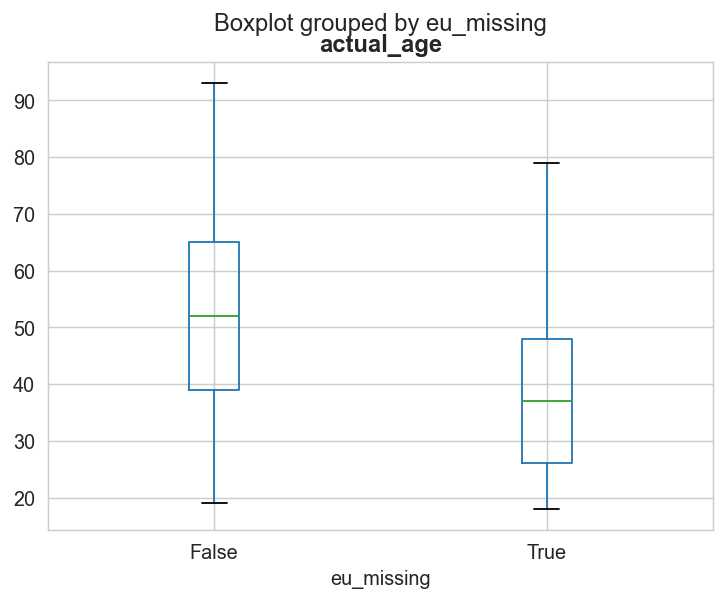

In [16]:
# is the EU-vote missingness itself informative, e.g. younger people not eligible in 2016?
eu_missing = raw_data[eu_col].isna().rename("eu_missing")
print(raw_data.groupby(eu_missing)["actual_age"].agg(["count", "mean", "median"]))
raw_data.assign(eu_missing=eu_missing).boxplot(column="actual_age", by="eu_missing")

In [17]:
# more generally: is EU-vote missingness predictable from any other column?
from sklearn.feature_selection import mutual_info_classif

def missingness_drivers(df, target_col, n=15):
    """Mutual information between `target_col` being missing and every other column."""
    y = df[target_col].isna().astype(int)
    X = df.drop(columns=[target_col])

    cols, discrete = {}, []
    for c in X.columns:
        s = X[c]
        if s.dtype.kind in "iuf" and s.nunique() > 10:   # continuous numeric
            cols[c] = s.fillna(s.median())
            discrete.append(False)
        else:                                            # categorical (or low-card numeric)
            cols[c] = pd.factorize(s)[0]                 # NaN -> -1, its own code
            discrete.append(True)

    mi = mutual_info_classif(pd.DataFrame(cols), y, discrete_features=discrete, random_state=0)
    return pd.Series(mi, index=X.columns).sort_values(ascending=False).head(n)

missingness_drivers(raw_data, eu_col)

voting_intention_which_party_would_you_vote_for_if_there_was_a_general_election_tomorrow                    0.078514
actual_age                                                                                                  0.059507
age                                                                                                         0.051731
political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics                  0.050872
serial_number                                                                                               0.038197
which_of_the_following_best_describes_your_current_working_status                                           0.035871
general_attitudes_britain_is_the_greatest_country_in_the_world                                              0.023020
general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies          0.022644
general_attitudes_government_should_always_put_the_needs_of_brit

The age split is mild and nothing else predicts the missingness strongly - it's close to random, which again maybe points to survey implementation rather than a meaningful non-response group. Given the proportion missing is manageable and EU vote is likely a useful predictor, I'll keep the column and fill the blanks with `No answer`.

That leaves `do_you_work_in`. With over half missing, I want to check whether it's a follow-up question only shown to certain people.

In [18]:
status_col   = "which_of_the_following_best_describes_your_current_working_status"
work_org_col = "work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for"

# Is 'do_you_work_in' a follow-up only shown to certain people? Break its missingness
# down by working status and by organisation type (row-normalised: share missing within
# each category) - if whole categories are all-missing/all-present, it's routed, not random.
display(pd.crosstab(raw_data[status_col],   raw_data[work_col].isna(), normalize="index"))
display(pd.crosstab(raw_data[work_org_col], raw_data[work_col].isna(), normalize="index"))
raw_data[work_col].value_counts(dropna=False)

do_you_work_in,False,True
which_of_the_following_best_describes_your_current_working_status,,
"House person, housewife, househusband, etc.",0.184615,0.815385
Not working and not seeking work/ Student,0.086207,0.913793
Not working/ temporarily unemployed/ sick but seeking work,0.157895,0.842105
Retired on a state pension only,0.080000,0.920000
Retired with a private pension,0.492958,0.507042
Working full time - working 30 hours per week or more,0.239437,0.760563
Working part time - working between 8 and 29 hours per week,0.192000,0.808000


do_you_work_in,False,True
work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for,,
Charity/ voluntary sector,0.0,1.0
Don't know,0.0,1.0
Have never worked,0.0,1.0
Nationalised industry or public corporation (e.g. Post Office),1.0,0.0
Other,0.0,1.0
Other public sector employer (e.g. Central Government),1.0,0.0
Private sector firm or company (e.g. limited companies and Plcs),0.0,1.0
Self-employed,0.0,1.0


do_you_work_in
NaN                                               1123
Education (schools, colleges and universities)     150
Other                                              139
Health and social care                              82
The military                                         3
Don't know                                           2
Name: count, dtype: int64

That's the explanation: `do_you_work_in` is a follow-up tied to working status and organisation type - it's only asked of certain (largely public-sector) respondents, so the blanks are "not applicable" rather than lost data. I'll keep it and, as with the others, fill the blanks with `No answer`.

So nothing gets dropped for missingness - the only column I remove is the single-value `..._dont_know` one. Everything else is either imputed with an explicit `No answer` category or left as is.

#### The target: voting intention

Last, a look at what I'm actually predicting. N.B. this contains the 20 repeated rows (Conservative voter), which I will drop in cleaning.

In [19]:
voting_col = TARGET_COL
inspection.response_counts(raw_data, voting_col)

,n,pct
response,,
Conservative,296,19.7
Labour,293,19.5
Don't know,276,18.4
Another party,219,14.6
Liberal Democrat,179,11.9
Would not vote,173,11.5
SNP,43,2.9
Plaid Cymru,11,0.7
Rather not say,9,0.6


The target has nine classes and is heavily imbalanced - Labour and Conservative dominate, the nationalist parties are very small, and three of the nine aren't parties at all (`Don't know`, `Would not vote`, `Rather not say`). I'm keeping all of them and I will address the imbalance at modelling.

### Clean the data
Based on the above exploration, we can now clean the data accordingly.

In [20]:
cols_to_remove = [
    "which_of_the_following_statements_apply_to_you_dont_know",
    # "which_of_the_following_statements_apply_to_you_i_own_more_than_one_property"
]
cols_with_missing_to_impute = [
    "do_you_work_in",
    "eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016",
    "which_of_the_following_statements_apply_to_you_i_own_more_than_one_property"
]
clean_data = (raw_data
              .pipe(clean.drop_duplicate_records)  # drop full-row duplicates
              .pipe(clean.remove_items, cols_to_remove)  # drop unwanted columns
              .pipe(clean.fill_missing_as_category, cols_with_missing_to_impute,
                    "No answer")  # fill NaNs with an explicit "No answer" category
              .pipe(clean.fix_encoding_errors)  # repair mojibake: u -> GBP in income bands
              )
display(clean_data)

,serial_number,gender,age,actual_age,which_of_the_following_best_describes_your_current_working_status,which_one_of_these_regions_do_you_live_in,what_is_the_combined_annual_income_of_your_household_prior_to_tax_being_deducted,work_organisation_please_tell_us_which_type_of_organisation_you_do_or_did_work_for,do_you_work_in,political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics,...,general_attitudes_britain_is_stronger_when_it_forms_partnerships_with_other_countries,general_attitudes_i_worry_that_cuts_in_defence_spending_mean_britain_can_no_longer_defend_itself,general_attitudes_the_government_should_prioritise_controlling_immigration_over_all_other_policies,general_attitudes_there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today,general_attitudes_government_should_always_put_the_needs_of_british_people_ahead_of_others,general_attitudes_the_uk_should_be_more_outward_looking_in_nature,general_attitudes_i_consider_myself_working_class,general_attitudes_big_business_takes_advantage_of_ordinary_people,goal_importance_most_important,voting_intention_which_party_would_you_vote_for_if_there_was_a_general_election_tomorrow
0,13,Male,65+,77,Retired on a state pension only,East of England,"£14,001 to £21,000",Private sector firm or company (e.g. limited c...,No answer,A great deal,...,Agree slightly,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Disagree strongly,Conserving the oceans,Conservative
1,14,Female,55-64,63,Retired with a private pension,West Midlands,"£14,001 to £21,000",Private sector firm or company (e.g. limited c...,No answer,A great deal,...,Neither agree nor disagree,Agree slightly,Agree slightly,Agree strongly,Agree strongly,Neither agree nor disagree,Disagree slightly,Agree slightly,"Industry, innovation, and infrastructure",Conservative
2,17,Female,65+,65,Retired on a state pension only,London,Prefer not to answer,Private sector firm or company (e.g. limited c...,No answer,Not very much,...,Agree strongly,Agree slightly,Neither agree nor disagree,Neither agree nor disagree,Agree strongly,Neither agree nor disagree,Agree slightly,Agree slightly,Conserving life on land,Liberal Democrat
3,18,Male,45-54,49,Working full time - working 30 hours per week ...,South West,"£34,001 to £41,000",Private sector firm or company (e.g. limited c...,No answer,Quite a lot,...,Agree strongly,Agree slightly,Disagree slightly,Agree slightly,Agree slightly,Agree slightly,Agree strongly,Neither agree nor disagree,Stopping climate change,Labour
4,19,Female,18-24,24,"House person, housewife, househusband, etc.",West Midlands,"£7,001 to £14,000",Private sector firm or company (e.g. limited c...,No answer,Some,...,Disagree slightly,Agree slightly,Neither agree nor disagree,Agree slightly,Agree strongly,Agree slightly,Agree slightly,Don't know,Providing quality education,Don't know
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1494,1862,Female,45-54,46,"House person, housewife, househusband, etc.",East of England,"£28,001 to £34,000",Other,No answer,Not very much,...,Don't know,Don't know,Don't know,Agree slightly,Agree strongly,Don't know,Don't know,Don't know,Good health and well-being,Would not vote
1495,1863,Male,25-34,27,Working full time - working 30 hours per week ...,West Midlands,"£34,001 to £41,000",Self-employed,No answer,Not very much,...,Disagree slightly,Agree slightly,Agree strongly,Agree slightly,Disagree strongly,Neither agree nor disagree,Neither agree nor disagree,Agree slightly,Ensuring nobody goes hungry,Would not vote
1496,1864,Male,35-44,38,Working full time - working 30 hours per week ...,Wales,"£21,001 to £28,000",Private sector firm or company (e.g. limited c...,No answer,A great deal,...,Disagree strongly,Agree strongly,Agree strongly,Disagree strongly,Agree strongly,Disagree strongly,Agree strongly,Agree strongly,Stopping climate change,Conservative
1497,1865,Female,18-24,22,

In [21]:
inspection.response_counts(clean_data, TARGET_COL)

,n,pct
response,,
Labour,293,20.0
Don't know,276,18.8
Conservative,265,18.1
Another party,219,14.9
Liberal Democrat,179,12.2
Would not vote,173,11.8
SNP,43,2.9
Plaid Cymru,11,0.7
Rather not say,9,0.6


wrote 01_target.png


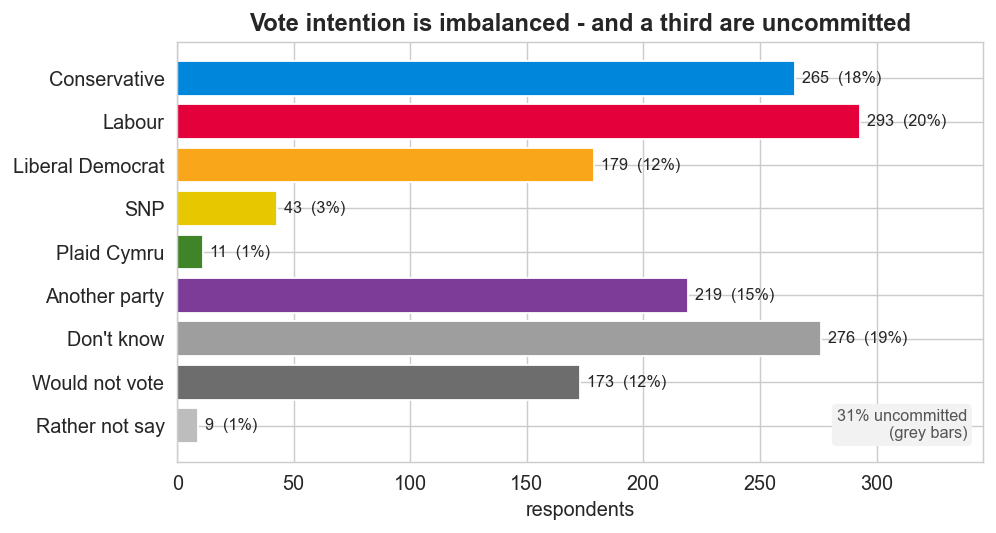

In [22]:
make_figures.plot_voting_intention(clean_data[TARGET_COL])

### Prepare data for analysis

In [23]:
# Encode and engineer ordinal data into numerical data
encoded_data = (clean_data
                .pipe(encode.engineer_attitudes)  # derive attitude features: signed scores, within-respondent z-scores, opinion strength, dk rate
                .pipe(encode.scale_political_interest)  # ordinal-encode political interest (0-4)
                .pipe(encode.encode_income)  # ordinal-encode income bands (+ refused flag)
                .pipe(encode.binarise_yes_no))  # map Yes/No columns to 1/0

In [24]:
X_all = encode.build_features(encoded_data, attitudes="normalised") # one-hot encoding
y_all = encoded_data[TARGET_COL]
X, y = X_all, y_all

### How do the attitudinal items relate to each other?

Before collapsing the `general_attitudes` items onto two value-map axes, I look at how all 11 of them (including `i_consider_myself_working_class`) correlate with each other, using the within-respondent z-scores. This sanity-checks the axis design: items I've assigned to the same pole should hang together (positive correlations), items on opposite poles should be negatively correlated, and the working-class identity item should *not* sit cleanly inside the economic block — which is why I hold it out of the axes and treat it as life-background instead.

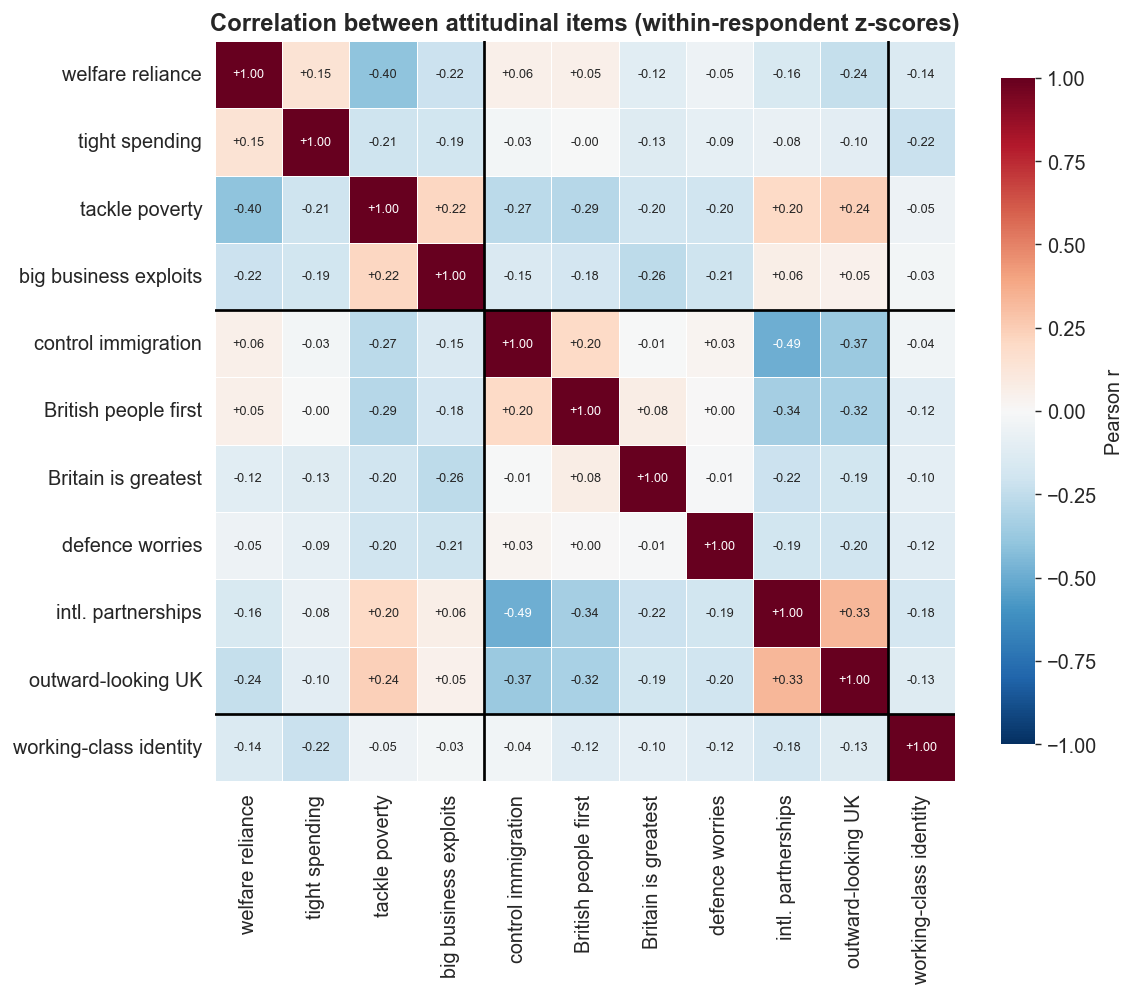

In [25]:
# Correlation matrix of all 11 attitudinal items (incl. working-class identity),
# using the within-respondent z-scores in X_all. Ordered econ items -> nat-int
# items -> class identity (the block ordering of the two value-map axes); raw item
# scores, so opposite-pole items within a block show up as negative correlations.
from config import ECON_AXIS, NATINT_AXIS
from helpers import pretty_labels

att_order = list(ECON_AXIS) + list(NATINT_AXIS) + ["i_consider_myself_working_class"]
att = pd.DataFrame({
    pretty_labels(stem): X_all[f"{ATTITUDE_PREFIX}_{stem}__z"]
    for stem in att_order
})
corr = att.corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .8, "label": "Pearson r"}, ax=ax)
# divider lines between the econ / nat-int / class-identity blocks
for pos in (len(ECON_AXIS), len(ECON_AXIS) + len(NATINT_AXIS)):
    ax.axhline(pos, color="k", lw=1.5)
    ax.axvline(pos, color="k", lw=1.5)
ax.set_title("Correlation between attitudinal items (within-respondent z-scores)")
fig.tight_layout()

### Curated political values map

Feature taxonomy lives in `config.py` (`ECON_AXIS`, `NATINT_AXIS`, `BACKGROUND_GROUPS`, `DEMOGRAPHIC_COLS`, `POLITICAL_COLS`). The two axes are built from the **values** items (`general_attitudes_*`) only — life-background facts, demographics and political background are held back for the random forest and profiling, so they don't contaminate the axis meaning.

Each axis = mean of the within-respondent z-scores of its items, signed so **+ = right (econ)** and **+ = nationalist (nat-int)**. If the vote separates here, the curated 2D view is justified; if not, that's the cue to fall back to the full feature set + random forest.

wrote 04_political_values_map.png


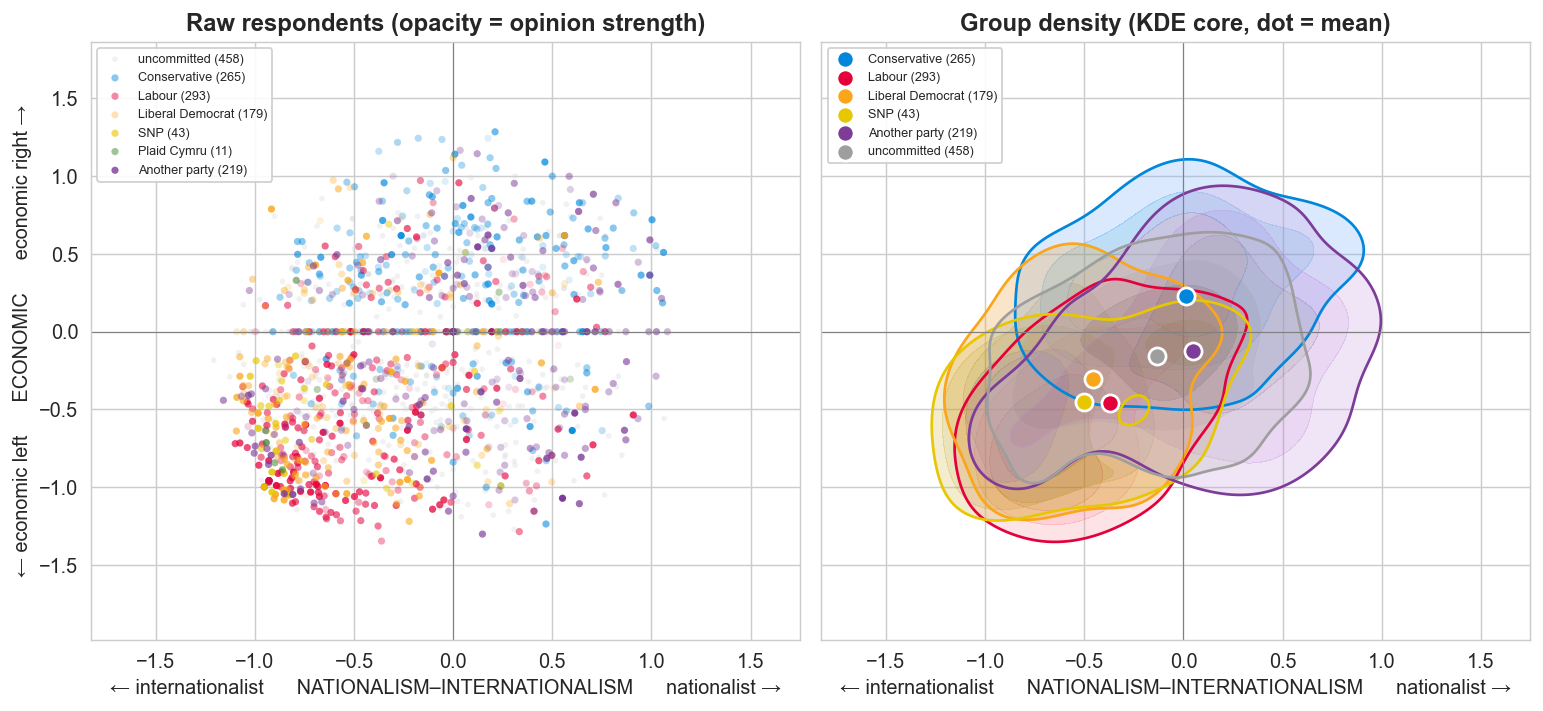

In [26]:
# Curated values map: every respondent on (econ, natint) from VALUES only
# (general_attitudes items), coloured by vote. All rows incl. undecided.
# opinion_strength (mean |score|, 0..2) lives in encoded_data, not X_all ->
# passed in to set point opacity: solid = opinionated, faint = no opinion.
importlib.reload(make_figures); import make_figures
make_figures.political_values_map(X_all, y_all, encoded_data["opinion_strength"])

**Reading the values map.** Every respondent is placed on my two curated value axes — economic (left ↔ right) and nationalism–internationalism (internationalist ↔ nationalist) — built from the `general_attitudes` items only. *Left:* raw respondents, with opacity set by opinion strength (faint = neutral / Don't know). *Right:* each group summarised as a KDE density blob with its mean.

The Conservatives pull cleanly to the economic right, but Labour, Lib Dem and SNP pile up together in the internationalist-left quadrant — on values alone these electorates aren't well separated, and the uncommitted (don't know / would not vote / rather not say) sit in the middle. I will explore this overlap further in the random forest and profiling, where life background, demographics and political background are included.

Two quirks. The horizontal band at **econ = 0** is *not* a cluster of centrists: my econ axis is balanced (two items each way), so anyone agreeing (or disagreeing) equally on both sides cancels to zero - the opacity shows many of these are actually strongly opinionated cross-pressured voters, not blank. And the **SNP mean sitting outside its blob** is small-sample skew.

In [27]:
# Sanity check: I excluded the general attitudes item 'i_consider_myself_working_class' from the values-based map axes. But lets confirm if it behaves like an economic value, or is more appropriate with life-background characteristics?

vmap = encode.value_map_scores(X_all)   # the (econ, natint) axes the values-map figure plots
wc = X_all[f"{ATTITUDE_PREFIX}_i_consider_myself_working_class__z"]
print(f"corr(working-class identity, econ axis)   = {vmap['econ'].corr(wc):+.3f}")
print(f"corr(working-class identity, nat-int axis) = {vmap['natint'].corr(wc):+.3f}")
print("\nfor scale, each genuine econ-VALUE item vs the econ axis:")
for stem in ECON_AXIS:
    r = vmap["econ"].corr(X_all[f"{ATTITUDE_PREFIX}_{stem}__z"])
    print(f"  {r:+.3f}  {stem}")

corr(working-class identity, econ axis)   = -0.108
corr(working-class identity, nat-int axis) = -0.016

for scale, each genuine econ-VALUE item vs the econ axis:
  +0.715  there_is_too_much_reliance_on_welfare_and_benefits_in_britain_today
  +0.564  keeping_a_tight_control_over_spending_should_be_the_governments_main_economic_priority
  -0.713  tackling_poverty_and_inequality_should_be_the_governments_top_priority
  -0.608  big_business_takes_advantage_of_ordinary_people


As expected, the 'i_consider_myself_working_class' question only weakly correlates with the economic axis (r=-0.108), therefore it is justified to separate it from the values-based map. It is more appropriate to treat it as a life-background characteristic, which will be used in the random forest and profiling.

### Random forest: curated vs full features

I'm choosing to use a random forest. I believe this is the right approach because it handles non-linearity and the mixed, mostly categorical data types natively. To confirm that, I compare it against logistic regression - a linear baseline - on the same features.

For model selection I hold out a stratified 20% test set first and keep all the CV on the training 80%, so the test set only gets use for model evaluation. The target is the raw 9-class vote on all rows, including the uncommitted.

Before trusting any score I check what 'no signal' looks like: a few dummy baselines, and a permutation test (shuffle the labels 100x and re-score) to get a chance distribution and a p-value. Then I choose what to include by running the forest across an ablation ladder - from demographics alone up to the full one-hot X_all - to see how much each block (demographics, life background, political background, values, and the rest) actually adds.

In [28]:
# Stratified hold-out; feature sets share identical columns, so we just subset rows.
# All CV / selection below is on train.
train_idx, test_idx = train_test_split(X_all.index, test_size=0.2, stratify=y_all, random_state=0)
y_tr, y_te = y_all.loc[train_idx], y_all.loc[test_idx]

feature_sets = encode.curated_feature_sets(X_all)   # demographics -> +background -> +political -> +values -> +style -> +priorities [curated] -> full
CHOSEN = "demographics+background+political+values+style+priorities [curated]"   # the set we keep after the comparison
SCORING = ("accuracy", "balanced_accuracy", "f1_macro")
print(f"train = {len(train_idx)}   test = {len(test_idx)}")

# what does 'no real signal' look like for this 9-class target?
print()
print("Dummy baselines (CV accuracy on train):")
print(model.dummy_baselines(feature_sets[CHOSEN].loc[train_idx], y_tr).to_string())

# permutation test on the chosen model: real CV accuracy vs labels-shuffled null (100x)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
score, perm, pval = permutation_test_score(
    model.make_rf_pipeline(), feature_sets[CHOSEN].loc[train_idx], y_tr,
    scoring="accuracy", cv=cv, n_permutations=100, n_jobs=-1, random_state=0)
print()
print(f"Permutation test (curated RF): real acc = {score:.3f}   "
      f"chance/null = {perm.mean():.3f} +/- {perm.std():.3f}   p = {pval:.3f}")

train = 1174   test = 294

Dummy baselines (CV accuracy on train):
most_frequent    0.199
stratified       0.152
uniform          0.113

Permutation test (curated RF): real acc = 0.364   chance/null = 0.167 +/- 0.012   p = 0.010


In [29]:
# Confirm the model choice: linear baseline vs forest on the full feature set.
# Same X for both, so any gap is down to what the model can represent, not the features.
model.compare_models(
    {"Logistic Regression": model.make_lr_pipeline(),
     "Random Forest":        model.make_rf_pipeline()},
    X_all.loc[train_idx], y_tr, scoring=SCORING)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,f1_macro_mean,f1_macro_std
Logistic Regression,0.354,0.033,0.310,0.046,0.309,0.049
Random Forest,0.372,0.013,0.336,0.011,0.306,0.014


The forest performs better, though not by a large margin - it wins on accuracy and balanced accuracy, while macro-F1 is about level. I will therefore continue with the random forest.

In [30]:
importlib.reload(model)
import model

In [31]:
rf_compare = {}
for name, Xs in feature_sets.items():
    s = model.cross_validate_model(model.make_rf_pipeline(impute=True), Xs.loc[train_idx], y_tr, scoring=SCORING)
    s["n_features"] = Xs.shape[1]
    rf_compare[name] = s
rf_compare = pd.DataFrame(rf_compare).T
rf_compare[["n_features", "accuracy_mean", "balanced_accuracy_mean", "f1_macro_mean"]].round(3)

,n_features,accuracy_mean,balanced_accuracy_mean,f1_macro_mean
demographics,38.0,0.223,0.261,0.219
demographics+background,56.0,0.263,0.310,0.256
demographics+background+political,60.0,0.325,0.371,0.313
demographics+background+political+values [curated],62.0,0.369,0.384,0.339
demographics+background+political+values+style [curated],65.0,0.371,0.381,0.335
demographics+background+political+values+style+priorities [curated],83.0,0.388,0.399,0.350
full X_all,92.0,0.377,0.360,0.325


The curated RF gets about 0.35 CV accuracy. That beats all three dummy baselines (the best of them, always-guess-Labour, gets 0.20) and is well clear of the permutation null — with the labels shuffled the model only reaches ~0.16 (p ≈ 0.01) — so it's picking up real signal, not noise. The accuracy is still low in absolute terms, but that's expected: three of the nine classes (Don't know, Would not vote, Rather not say) aren't parties and carry no party signal, and two of the real parties are tiny.

Reading down the ladder, I can see how much each group of features adds as they're stacked on. Demographics on their own get to ~0.20 accuracy — only just above always-guessing-Labour (though clearly above chance on balanced accuracy, 0.27). Life background, political background (political interest and EU-referendum vote), and the value axes on top add more accuracy to the model. No single type of feature dominates so a combination is needed to separate the parties.

The curated set (62 features) does about as well as the full one-hot X_all (92 features) on accuracy, and a bit better on balanced accuracy (0.35 vs 0.34), so I'll keep it from here. 

### Which curated blocks carry the signal?

The ablation ladder above shows how much each *layer* adds. Here I look *within* the chosen curated set at which blocks the forest actually uses, grouped by my taxonomy — the two value axes, the three life-background sub-domains, each demographic question, and each political-background question. Two complementary views (both on the train split, scored on **balanced accuracy** since the 9-class target is very imbalanced):

- **Grouped permutation importance** — shuffle one block's columns and measure the drop in balanced accuracy. This is the block's *unique* contribution *given everything else*; a block that is redundant with another scores ~0 even if it carries signal. Stars mark a one-sided t-test that the per-fold drop is > 0.
- **Standalone power** — fit a model on one block alone. This is its *raw* signal, ignoring redundancy. Stars test against the ~1/9 chance floor.

The gap between the two is the interesting part. A block that predicts well alone but adds nothing on top of the rest is **redundant** with another block. In particular this is how I check whether the **cosmopolitan** background block is just a behavioural echo of the **nationalism–internationalism** value axis (notes, point 50): strong standalone, near-zero unique → redundant.

In [32]:
# Curated-block feature importance on the chosen set (train split only).
# Reload the edited modules so config/encode/model changes apply without a kernel restart.
import importlib, config
importlib.reload(config); importlib.reload(encode); importlib.reload(model); importlib.reload(helpers)
from helpers import stars, pretty_labels
from scipy.stats import ttest_1samp

X_imp = feature_sets[CHOSEN].loc[train_idx]      # curated matrix carries the 'econ'/'natint' value axes
groups = encode.curated_groups(X_imp)            # values (econ/natint) + life-background sub-domains + each demo + political question

# Shuffle each block, measure the drop in balanced accuracy -> its unique contribution.
imp = model.grouped_permutation_importance(
    model.make_rf_pipeline, X_imp, y_tr, groups,
    cv=10, n_repeats=10, score_fn=balanced_accuracy_score)

wrote 06_permutation_importance.png


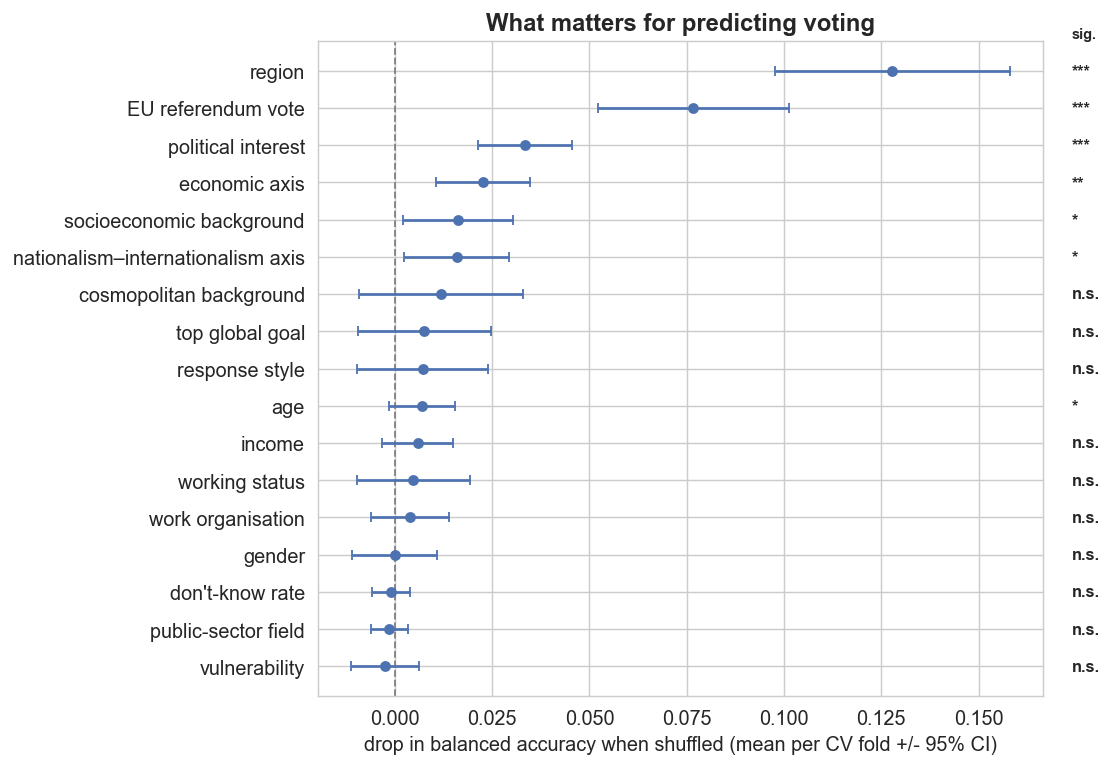

In [33]:
# Mean +/- 95% CI drop in balanced accuracy when each block is shuffled, ranked
# (most important at the top). CI is the t-based interval of the per-fold mean.
importlib.reload(make_figures); import make_figures
make_figures.permutation_importance_plot(imp)

significant blocks (p < 0.05): ['region', 'eu_referendum', 'political_interest', 'econ', 'socioeconomic', 'natint', 'actual_age']
wrote 03_vote_mix_by_feature.png


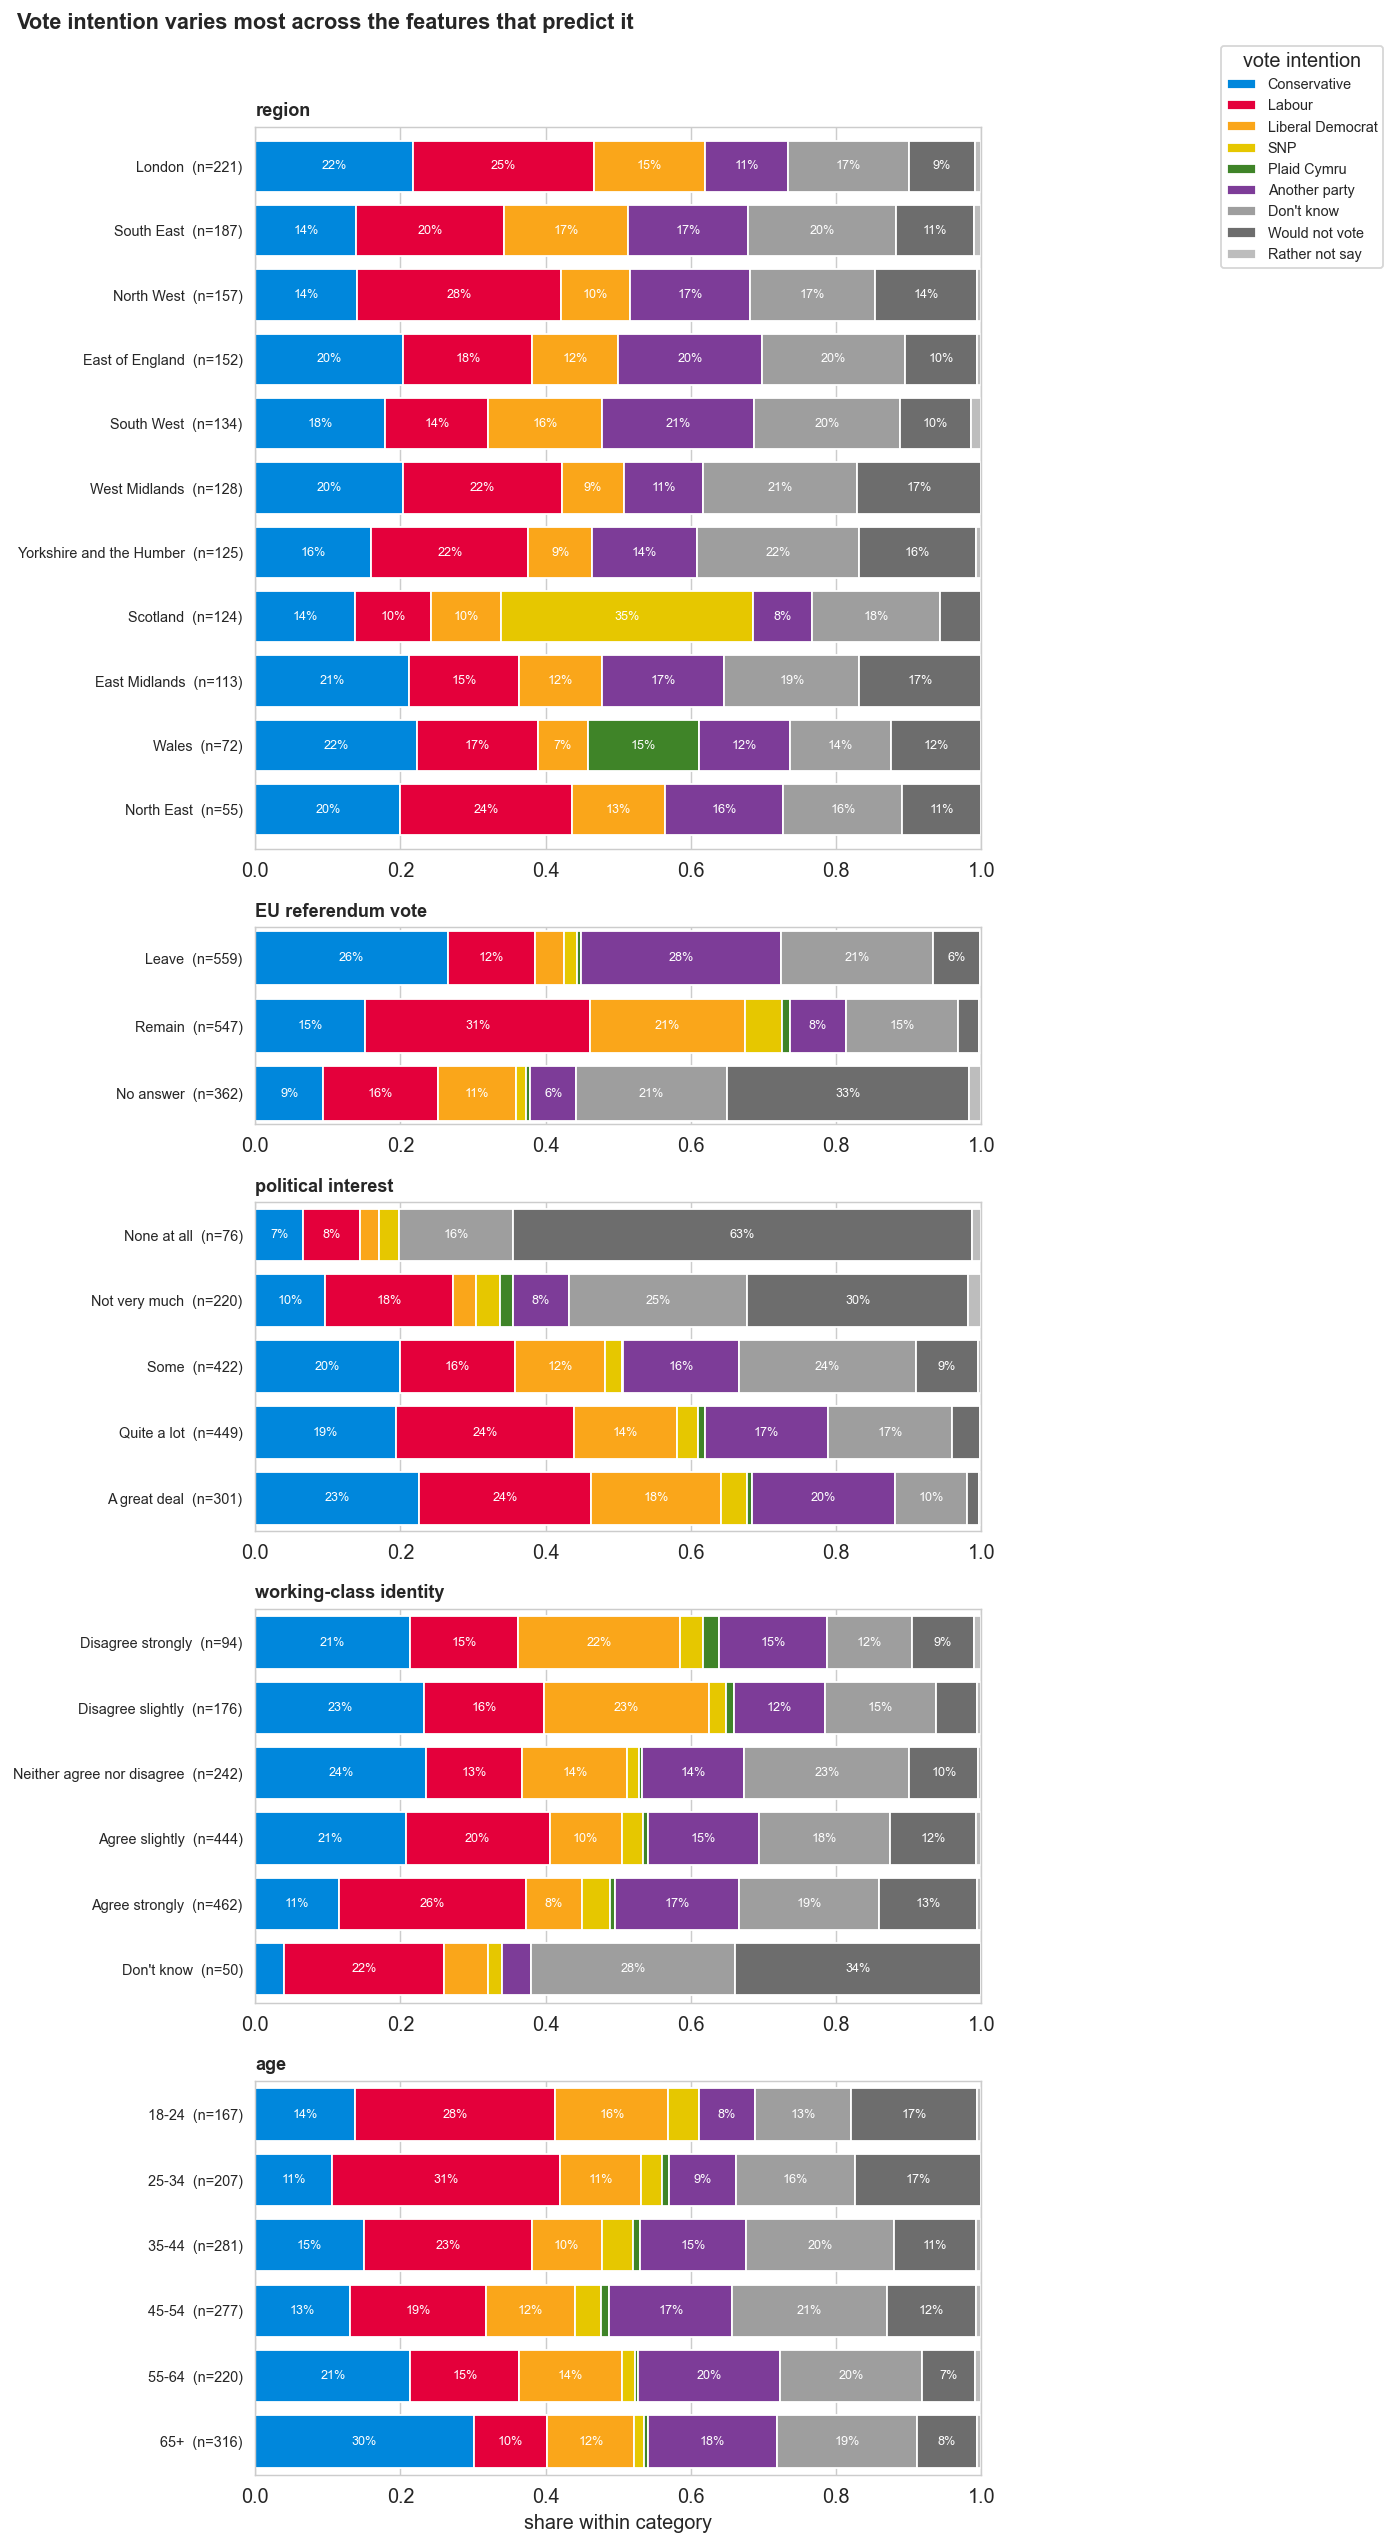

In [34]:
# Descriptive companion to the importance plot above: for the blocks that actually
# *matter* (significant drop when shuffled), show how each category splits by vote
# intention on the WHOLE dataset (undecided included). Description, not prediction -
# it makes the model's "what matters" concrete. I show the strongest, readable blocks
# (region, EU vote, political interest, working-class identity, age); the value axes are
# already on the values map and the rest of class_position is shown in the standalone mix.
from helpers import FRIENDLY
from config import BACKGROUND_GROUPS

# Block ranking + p-values straight from `imp`, kept for the printout / transparency.
_feat_cols = [c for c in imp.columns if c != "_fold"]
_fold_means = imp.groupby("_fold")[_feat_cols].mean()
blocks_by_importance = _fold_means.mean().sort_values(ascending=False).index
block_pvals = {c: ttest_1samp(_fold_means[c], 0, alternative="greater").pvalue
               for c in _feat_cols}
print("significant blocks (p < 0.05):",
      [b for b in blocks_by_importance if block_pvals[b] < 0.05])

# The curated, readable subset used in the write-up (banded age for legibility).
sig_features = [
    "which_one_of_these_regions_do_you_live_in",
    "eu_referendum_how_did_you_vote_in_the_eu_referendum_in_june_2016",
    "political_interest_how_much_interest_do_you_generally_have_in_what_is_going_on_in_politics",
    "general_attitudes_i_consider_myself_working_class",
    "age",
]

importlib.reload(make_figures); import make_figures
make_figures.plot_vote_mix_by_feature(clean_data, sig_features)

wrote 07_standalone_power.png


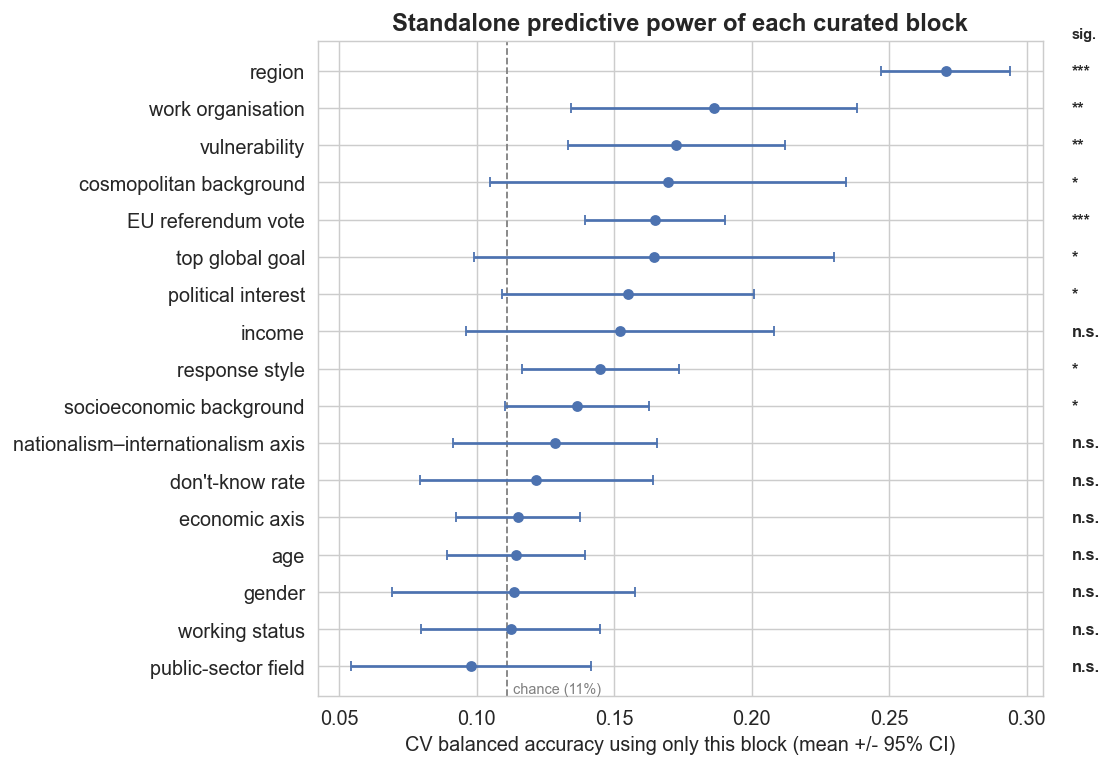

In [35]:
# Standalone power: fit a model on ONLY each block's columns.
uni = model.univariate_score(
    model.make_rf_pipeline, X_imp, y_tr, groups, cv=10, score_fn=balanced_accuracy_score)

# Mean +/- 95% CI held-out balanced accuracy per block, ranked, vs the 1/9 chance floor.
importlib.reload(make_figures); import make_figures
make_figures.standalone_power_plot(uni, n_classes=y_tr.nunique())

standalone-significant features shown: 21
wrote 05_vote_mix_standalone.png


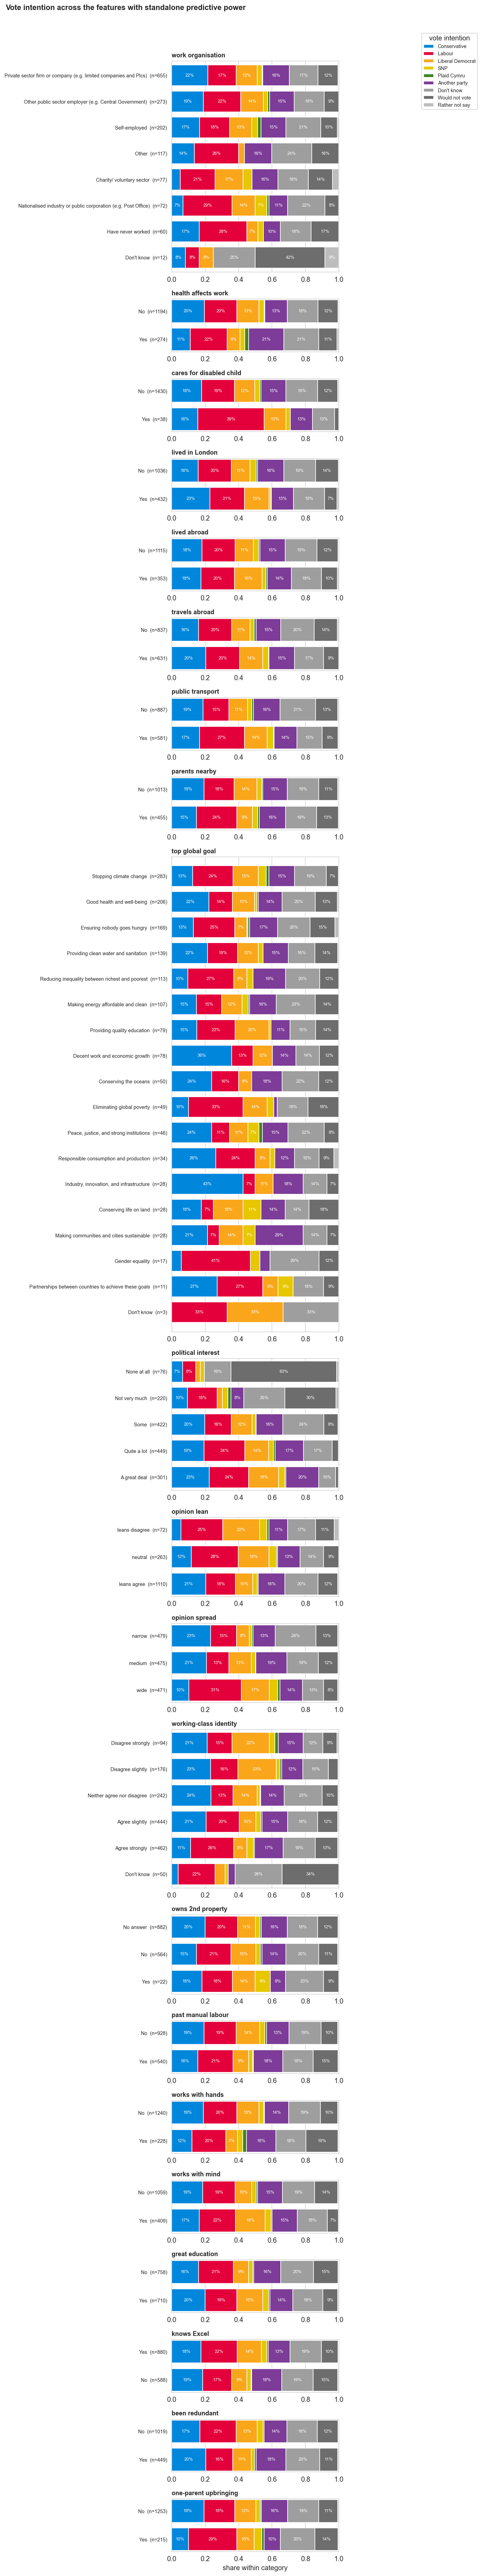

In [36]:
# Descriptive companion to the standalone predictive-power plot above: for the blocks
# that predict vote on their OWN (significant in the univariate analysis, p < 0.05),
# show how each category splits by vote intention on the WHOLE dataset (undecided
# included). These are the standalone-significant blocks not already shown in the
# ablation vote-mix earlier (region / EU vote / age), so the two figures together cover
# both "what matters given everything else" and "what predicts on its own". Description,
# not prediction.
from config import (BACKGROUND_GROUPS, DEMOGRAPHIC_BLOCKS, POLITICAL_BLOCKS, PRIORITY_BLOCKS)

# The response-style features are continuous and live in encoded_data, so I bin them
# into readable bands to sit in the same stacked-bar view as the survey questions.
plot_df = clean_data.copy()
plot_df["opinion_lean"] = pd.cut(
    encoded_data["opinion_mean"], [-2.01, -0.25, 0.25, 2.01],
    labels=["leans disagree", "neutral", "leans agree"])
plot_df["opinion_spread"] = pd.qcut(
    encoded_data["opinion_std"], 3, labels=["narrow", "medium", "wide"])

standalone_blocks = (
    DEMOGRAPHIC_BLOCKS["work_organisation"]      # work organisation
    + BACKGROUND_GROUPS["vulnerability"]          # all vulnerability items
    + BACKGROUND_GROUPS["cosmopolitan"]           # all cosmopolitan-background items
    + PRIORITY_BLOCKS["goal_importance"]          # top global goal
    + POLITICAL_BLOCKS["political_interest"]      # political interest
    + ["opinion_lean", "opinion_spread"]          # response style (binned)
    + BACKGROUND_GROUPS["socioeconomic"]         # all class-position items
)
# socioeconomic's working-class item is the encoded __z column -> swap in the readable
# agree/disagree question from clean_data.
standalone_features = [
    "general_attitudes_i_consider_myself_working_class"
    if c.endswith("i_consider_myself_working_class__z") else c
    for c in standalone_blocks]
standalone_features = [c for c in standalone_features if c in plot_df.columns]

orders = {
    "opinion_lean":   ["leans disagree", "neutral", "leans agree"],
    "opinion_spread": ["narrow", "medium", "wide"],
}
print("standalone-significant features shown:", len(standalone_features))

importlib.reload(make_figures); import make_figures
make_figures.plot_vote_mix_by_feature(
    plot_df, standalone_features, orders=orders, name="05_vote_mix_standalone.png",
    title="Vote intention across the features with standalone predictive power")

### Model evaluation: held-out test accuracy

I now fit the curated model on the training data and score it on the held-out 20% to see how the model performs on unseen data.

In [37]:
# Fit model on all the training data, then score the test set once.
clf = model.make_rf_pipeline().fit(feature_sets[CHOSEN].loc[train_idx], y_tr)
pred = clf.predict(feature_sets[CHOSEN].loc[test_idx])
print(f"{CHOSEN}:  test acc = {accuracy_score(y_te, pred):.3f}   "
      f"balanced acc = {balanced_accuracy_score(y_te, pred):.3f}")
print()
print(classification_report(y_te, pred, zero_division=0))

demographics+background+political+values+style+priorities [curated]:  test acc = 0.391   balanced acc = 0.366

                  precision    recall  f1-score   support

   Another party       0.29      0.30      0.29        44
    Conservative       0.43      0.43      0.43        53
      Don't know       0.32      0.16      0.22        55
          Labour       0.50      0.53      0.51        59
Liberal Democrat       0.29      0.33      0.31        36
     Plaid Cymru       0.00      0.00      0.00         2
  Rather not say       0.00      0.00      0.00         2
             SNP       0.38      1.00      0.55         8
  Would not vote       0.45      0.54      0.49        35

        accuracy                           0.39       294
       macro avg       0.30      0.37      0.31       294
    weighted avg       0.38      0.39      0.38       294



A single accuracy is hard to read on its own, so I compare it to the trivial baselines on the *same* held-out test set. Always guessing Labour gets about 0.20, so the curated forest at 0.38 is clearly doing real work. The paired bootstrap below puts the gap over 'always Labour' at roughly +0.18 with a 95% interval well clear of zero, so the improvement holds on unseen data, not just in CV.

In [38]:
# Is 0.37 good? Compare to trivial baselines on the SAME held-out test set.
Xtr, Xte = feature_sets[CHOSEN].loc[train_idx], feature_sets[CHOSEN].loc[test_idx]
rows = {"curated RF": accuracy_score(y_te, pred)}
rows["most_frequent (always Labour)"] = accuracy_score(
    y_te, DummyClassifier(strategy="most_frequent").fit(Xtr, y_tr).predict(Xte))
rows["stratified"] = accuracy_score(
    y_te, DummyClassifier(strategy="stratified", random_state=0).fit(Xtr, y_tr).predict(Xte))
print("Held-out test accuracy:")
print(pd.Series(rows).round(3).to_string())

# paired bootstrap: how far does the RF beat 'always Labour' on the test set?
mf_pred = DummyClassifier(strategy="most_frequent").fit(Xtr, y_tr).predict(Xte)
yt = y_te.to_numpy()
rng = np.random.default_rng(0)
gap = np.array([accuracy_score(yt[ix], pred[ix]) - accuracy_score(yt[ix], mf_pred[ix])
                for ix in (rng.integers(0, len(yt), len(yt)) for _ in range(10000))])
print()
print(f"RF - most_frequent: {gap.mean():+.3f}   "
      f"95% CI [{np.quantile(gap, .025):+.3f}, {np.quantile(gap, .975):+.3f}]")


Held-out test accuracy:
curated RF                       0.391
most_frequent (always Labour)    0.201
stratified                       0.180

RF - most_frequent: +0.190   95% CI [+0.122, +0.255]


I only get one number from a single test set, and it doesn't say how much it might wobble - and some classes are tiny. So I bootstrap the test set (resample the 294 rows with replacement, 2000 times) to put a 95% interval on the overall accuracy and on each party's recall (recall = of the people who really vote party X, how many I catch). The point estimates match the report above; the intervals show which ones I can actually trust - e.g. SNP looks great until you see how wide its interval is.

In [39]:
# Bootstrap the held-out test set for uncertainty: resample test rows (with replacement)
# and recompute each metric -> 95% percentile CIs. clf is not retrained, so this is the
# test-set sampling noise for this one fixed model.
rng = np.random.default_rng(0)
y_true = y_te.to_numpy()
classes = sorted(y_te.unique())

def test_metrics(ix):
    a, b = y_true[ix], pred[ix]
    out = {"accuracy": accuracy_score(a, b), "balanced_acc": balanced_accuracy_score(a, b)}
    for c in classes:
        m = a == c
        out[f"recall:{c}"] = (b[m] == c).mean() if m.any() else np.nan
    return out

boot = pd.DataFrame([test_metrics(rng.integers(0, len(y_true), len(y_true))) for _ in range(2000)])
ci = boot.quantile([0.025, 0.975]).T
test_ci = pd.DataFrame({"estimate": pd.Series(test_metrics(np.arange(len(y_true)))),
                        "lo95": ci[0.025], "hi95": ci[0.975]}).round(3)
test_ci["support"] = [len(y_true), len(y_true)] + [int((y_true == c).sum()) for c in classes]
test_ci

,estimate,lo95,hi95,support
accuracy,0.391,0.333,0.446,294
balanced_acc,0.366,0.330,0.446,294
recall:Another party,0.295,0.162,0.436,44
recall:Conservative,0.434,0.295,0.577,53
recall:Don't know,0.164,0.073,0.268,55
recall:Labour,0.525,0.396,0.651,59
recall:Liberal Democrat,0.333,0.185,0.500,36
recall:Plaid Cymru,0.000,0.000,0.000,2
recall:Rather not say,0.000,0.000,0.000,2
recall:SNP,1.000,1.000,1.000,8


The confusion matrix, normalised by row (each row is the actual voters of one party, columns are where the model sends them), makes the per-class story concrete - the diagonal is recall. It shows which parties get confused for which, and how the uncommitted and the small parties get absorbed into the big three.

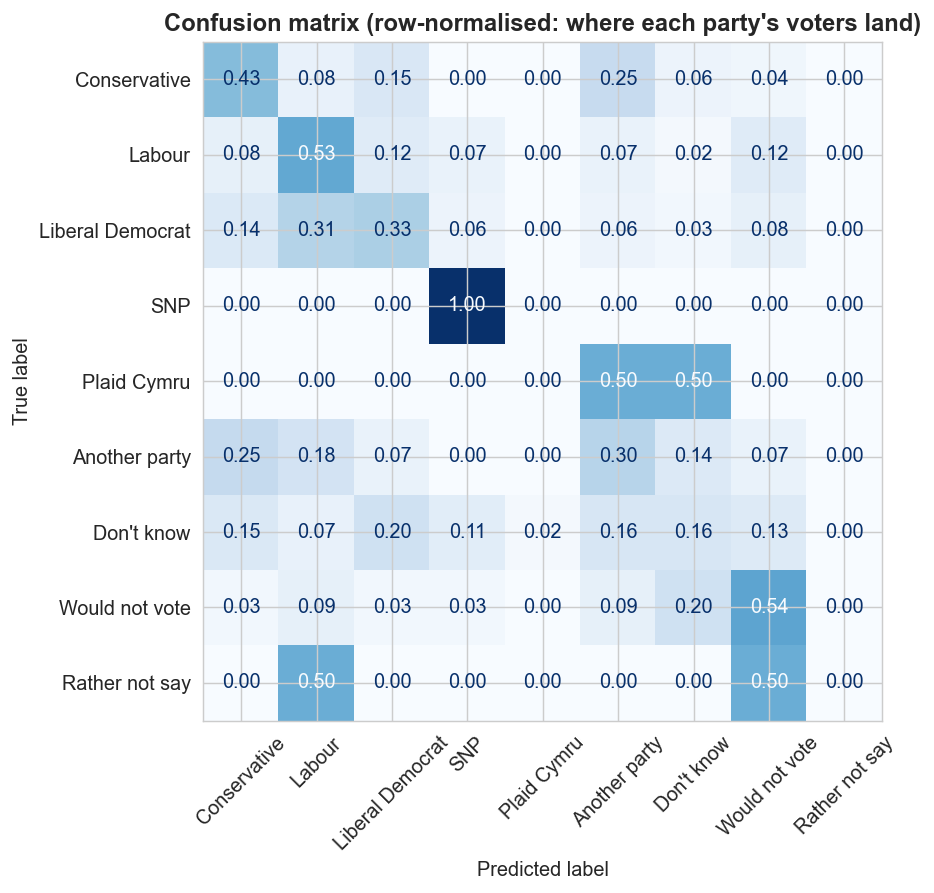

In [40]:
order = ["Conservative", "Labour", "Liberal Democrat", "SNP", "Plaid Cymru",
         "Another party", "Don't know", "Would not vote", "Rather not say"]
order = [c for c in order if c in set(y_te)]
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_te, pred, labels=order, normalize="true", values_format=".2f",
    cmap="Blues", colorbar=False, xticks_rotation=45, ax=ax)
ax.set_title("Confusion matrix (row-normalised: where each party's voters land)")
fig.tight_layout()

The model isnt perfect at predicting voting intention, however it tends to get it wrong in sensible places. For example, liberal democrat voters are predicted as labour voters but rarely any other party. Labour voters are raely predicted as anything else on the other hand. Furthermore, conservative viters are often predicted as voting for another party.